In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# === Folder containing results ===
results_folder = "results_5x_1.1Wz"
tension_folder = os.path.join(results_folder, "tension_plots")
momentum_folder = os.path.join(results_folder, "momentum_plots")
os.makedirs(tension_folder, exist_ok=True)
os.makedirs(momentum_folder, exist_ok=True)

# === Simulation parameters ===
L = 20.0
N = 50
EA = 1e5
l_k = L / N
h = 1e-4
ds = 1000          # downsample factor
window = 1.0       # integration window [s]
window_steps = int(window / h)
window_ds = max(1, window_steps // ds)  # window width in downsampled samples

# === Helpers ===
def reshape_to_nodes3(traj):
    """
    Accepts trajectories shaped (T, flat_dim) or (T, N, 3) and returns (T, N, 3).
    """
    if traj.ndim == 3 and traj.shape[-1] == 3:
        return traj
    elif traj.ndim == 2:
        T, flat = traj.shape
        N_guess = flat // 3
        assert 3 * N_guess == flat, "flat_dim not divisible by 3"
        return traj.reshape(T, N_guess, 3)
    else:
        raise ValueError(f"Unexpected traj shape: {traj.shape}")

def compute_drone_tension(q):
    """
    Drone-side tension magnitude using last segment.
    q: (num_nodes, 3) positions for one time step
    """
    diff = q[-1] - q[-2]
    length = np.linalg.norm(diff)
    # guard against zero-length (degenerate) cases
    if length == 0.0:
        return 0.0
    stretch = (length - l_k) / length
    T_vec = (EA / l_k) * stretch * diff
    return float(np.linalg.norm(T_vec))

def moving_average(x, w=50):
    if len(x) < w:
        # if series is shorter than window, just return a copy
        return x.copy()
    return np.convolve(x, np.ones(w)/w, mode="valid")

def extract_omega(fname):
    m = re.search(r"omega(-?\d+(?:\.\d+)?)", fname)
    return float(m.group(1)) if m else None

# === Gather files and (optionally) sort by omega value ===
files = [f for f in os.listdir(results_folder) if f.endswith(".npz")]
# Pair with omega for stable numeric sort; missing omega -> +inf so it goes last
paired = []
for f in files:
    w = extract_omega(f)
    paired.append((float("inf") if w is None else w, f))
paired.sort(key=lambda t: t[0])
sorted_files = [f for _, f in paired]

# === Process each file ===
for fname in sorted_files:
    filepath = os.path.join(results_folder, fname)
    data = np.load(filepath)
    traj_nodes = data["trajectories"]  # (T, N, 3)

    num_steps, num_nodes, _ = traj_nodes.shape
    time = np.arange(num_steps) * h
    time_ds = time[::ds]

    # ---- Downsampled drone tension (raw) ----
    tensions_ds = [compute_drone_tension(traj_nodes[j])
                   for j in range(0, num_steps, ds)]
    tensions_ds = np.array(tensions_ds, dtype=float)

    # ---- Smoothed drone tension ----
    smoothed_tension = moving_average(tensions_ds, w=50)
    time_smoothed = time_ds[:len(smoothed_tension)]

    # ---- Plot: Drone Tension (raw + smoothed) ----
    omega_val = extract_omega(fname)
    title = (f"Drone Tension vs Time (ω = {omega_val:.3f})"
             if omega_val is not None else "Drone Tension vs Time")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time_ds, tensions_ds, lw=0.8, alpha=0.6, label="Raw")
    ax.plot(time_smoothed, smoothed_tension, "r-", lw=2, label="Smoothed")
    ax.axhline(np.mean(smoothed_tension), color="g", linestyle="--",
               label=f"Mean = {np.mean(smoothed_tension):.2f}")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("Drone Tension")
    ax.set_title(title); ax.legend(); ax.grid(True); fig.tight_layout()

    out_name_t = (f"drone_tension_{omega_val:.3f}.png"
                  if omega_val is not None else f"drone_tension_{os.path.splitext(fname)[0]}.png")
    fig.savefig(os.path.join(tension_folder, out_name_t), dpi=200)
    plt.close(fig)

    # ---- Momentum change (impulse) from SMOOTHED tension ----
    # integrate over sliding 1s windows on the smoothed signal
    momentum_changes = []
    for k in range(len(smoothed_tension) - window_ds):
        y = smoothed_tension[k:k+window_ds]
        x = time_smoothed[k:k+window_ds]
        impulse = np.trapezoid(y, x)
        momentum_changes.append(impulse)
    momentum_changes = np.array(momentum_changes)
    time_mc = time_smoothed[:len(momentum_changes)]

    # Smooth momentum curve
    smoothed_mc = moving_average(momentum_changes, w=20)
    time_mc_sm = time_mc[:len(smoothed_mc)]

    # === Plot Momentum Change (smoothed only) ===
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time_mc_sm, smoothed_mc, "r-", lw=2,
            label="Momentum Change (smoothed)")

    avg_val_mc = np.mean(smoothed_mc)
    ax.axhline(avg_val_mc, color="g", linestyle="--",
               label=f"Mean = {avg_val_mc:.2f}")

    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Momentum Change (Impulse)")
    title_mc = (f"Momentum Change @ {omega_val:.3f} Hz (Window = {window:.1f} s)"
                if omega_val is not None else f"Momentum Change (Window = {window:.1f} s)")
    ax.set_title(title_mc)
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    save_name_mc = f"momentum_change_{omega_val:.3f}Hz.png" if omega_val else "momentum_change.png"
    fig.savefig(os.path.join(momentum_folder, save_name_mc), dpi=200)
    plt.close(fig)

print(f"Saved plots into:\n- {tension_folder}\n- {momentum_folder}")


Saved plots into:
- results_5x_1.1Wz/tension_plots
- results_5x_1.1Wz/momentum_plots


In [5]:

import numpy as np
import matplotlib.pyplot as plt
import os
import re

# === Folder containing results ===
results_folder = "results_5x_1.1Wz"
tension_folder = os.path.join(results_folder, "tension_plots_100s")
momentum_folder = os.path.join(results_folder, "momentum_plots_100s")
os.makedirs(tension_folder, exist_ok=True)
os.makedirs(momentum_folder, exist_ok=True)

# === Simulation parameters ===
L = 20.0
N = 50
EA = 1e5
l_k = L / N
h = 1e-4
ds = 1000          # downsample factor
window = 1.0       # integration window [s]
window_steps = int(window / h)
window_ds = max(1, window_steps // ds)  # window width in downsampled samples

# === Helpers ===
def compute_drone_tension(q):
    diff = q[-1] - q[-2]
    length = np.linalg.norm(diff)
    if length == 0.0:
        return 0.0
    stretch = (length - l_k) / length
    T_vec = (EA / l_k) * stretch * diff
    return float(np.linalg.norm(T_vec))

def moving_average(x, w=50):
    if len(x) < w:
        return x.copy()
    return np.convolve(x, np.ones(w)/w, mode="valid")

def extract_omega(fname):
    m = re.search(r"omega(-?\d+(?:\.\d+)?)", fname)
    return float(m.group(1)) if m else None

def annotate_curve(ax, x, y, n=6, color="black"):
    """Annotate n evenly spaced points on (x,y) curve."""
    if len(x) == 0: return
    step = max(1, len(x)//n)
    for idx in range(0, len(x), step):
        ax.annotate(f"{y[idx]:.2f}", (x[idx], y[idx]),
                    textcoords="offset points", xytext=(0,10),
                    ha="center", fontsize=8, color=color)

# === Gather files and sort by omega value ===
files = [f for f in os.listdir(results_folder) if f.endswith(".npz")]
paired = [(extract_omega(f) if extract_omega(f) is not None else float("inf"), f) for f in files]
paired.sort(key=lambda t: t[0])
sorted_files = [f for _, f in paired]

# === Process each file ===
for fname in sorted_files:
    filepath = os.path.join(results_folder, fname)
    data = np.load(filepath)
    traj_nodes = data["trajectories"]  # (T, N, 3)
    num_steps, num_nodes, _ = traj_nodes.shape
    time = np.arange(num_steps) * h

    # limit to 100s
    max_steps = int(100.0 / h)
    traj_nodes = traj_nodes[:max_steps]
    time = time[:max_steps]
    time_ds = time[::ds]

    # ---- Downsampled drone tension (raw) ----
    tensions_ds = [compute_drone_tension(traj_nodes[j])
                   for j in range(0, len(traj_nodes), ds)]
    tensions_ds = np.array(tensions_ds, dtype=float)

    # ---- Smoothed drone tension ----
    smoothed_tension = moving_average(tensions_ds, w=50)
    time_smoothed = time_ds[:len(smoothed_tension)]

    # ---- Plot: Drone Tension (raw + smoothed) ----
    omega_val = extract_omega(fname)
    title = (f"Drone Tension vs Time (first 100s, ω = {omega_val:.3f})"
             if omega_val is not None else "Drone Tension vs Time (first 100s)")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time_ds, tensions_ds, lw=0.8, alpha=0.6, label="Raw")
    ax.plot(time_smoothed, smoothed_tension, "r-", lw=2, label="Smoothed")
    ax.axhline(np.mean(smoothed_tension), color="g", linestyle="--",
               label=f"Mean = {np.mean(smoothed_tension):.2f}")
    annotate_curve(ax, time_smoothed, smoothed_tension, n=6, color="red")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("Drone Tension")
    ax.set_title(title); ax.legend(); ax.grid(True); fig.tight_layout()

    out_name_t = f"drone_tension_{omega_val:.3f}_100s.png" if omega_val is not None else f"drone_tension_{os.path.splitext(fname)[0]}_100s.png"
    fig.savefig(os.path.join(tension_folder, out_name_t), dpi=200)
    plt.close(fig)

    # ---- Momentum change (impulse) from SMOOTHED tension ----
    momentum_changes = []
    for k in range(len(smoothed_tension) - window_ds):
        y = smoothed_tension[k:k+window_ds]
        x = time_smoothed[k:k+window_ds]
        impulse = np.trapezoid(y, x)
        momentum_changes.append(impulse)
    momentum_changes = np.array(momentum_changes)
    time_mc = time_smoothed[:len(momentum_changes)]

    # Smooth momentum curve
    smoothed_mc = moving_average(momentum_changes, w=20)
    time_mc_sm = time_mc[:len(smoothed_mc)]

    # ---- Plot Momentum Change (smoothed only) ----
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time_mc_sm, smoothed_mc, "r-", lw=2,
            label="Momentum Change (smoothed)")
    avg_val_mc = np.mean(smoothed_mc)
    ax.axhline(avg_val_mc, color="g", linestyle="--",
               label=f"Mean = {avg_val_mc:.2f}")
    annotate_curve(ax, time_mc_sm, smoothed_mc, n=6, color="blue")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Momentum Change (Impulse)")
    title_mc = (f"Momentum Change first 100s @ {omega_val:.3f} Hz"
                if omega_val is not None else "Momentum Change (first 100s)")
    ax.set_title(title_mc)
    ax.legend(); ax.grid(True); fig.tight_layout()

    save_name_mc = f"momentum_change_{omega_val:.3f}_100s.png" if omega_val else "momentum_change_100s.png"
    fig.savefig(os.path.join(momentum_folder, save_name_mc), dpi=200)
    plt.close(fig)

print(f"Saved 100s plots into:\n- {tension_folder}\n- {momentum_folder}")


Saved 100s plots into:
- results_5x_1.1Wz/tension_plots_100s
- results_5x_1.1Wz/momentum_plots_100s


tesnsion plot check

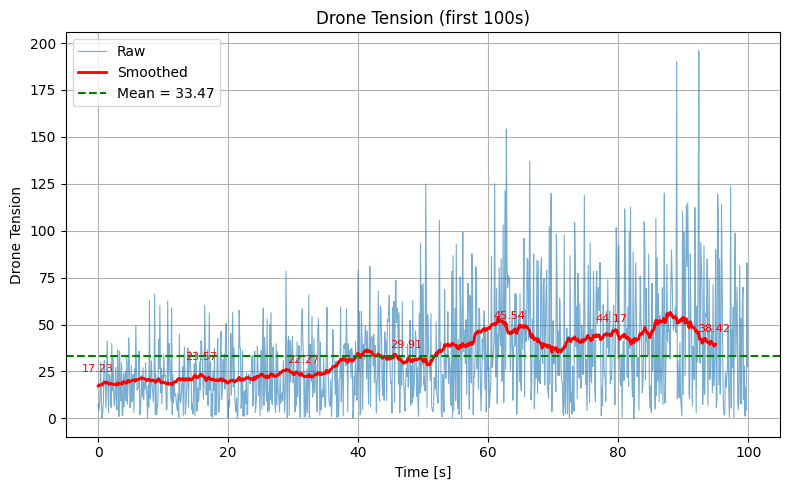

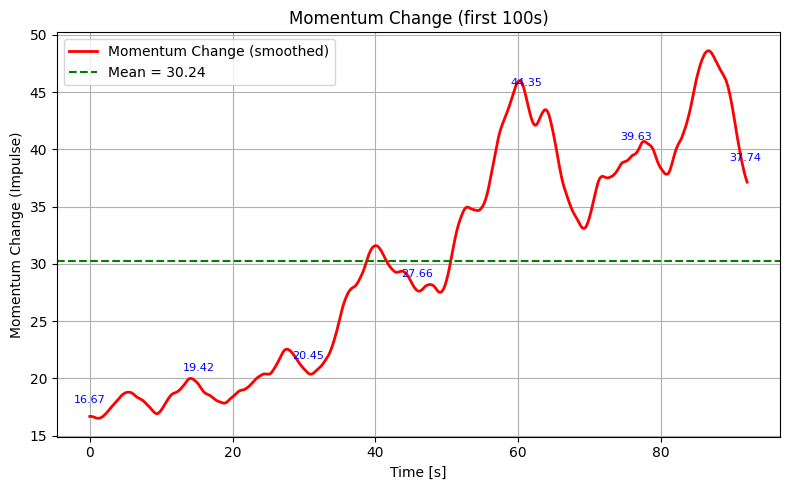

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# === Test file ===
test_file = "results_5x_1.1Wz/sim_rank3_omega0.300_tf500.0s_L20.0_N50.npz"

# === Simulation parameters ===
L = 20.0
N = 50
EA = 1e5
l_k = L / N
h = 1e-4
ds = 1000
window = 1.0
window_steps = int(window / h)
window_ds = max(1, window_steps // ds)

# === Helpers ===
def compute_drone_tension(q):
    diff = q[-1] - q[-2]
    length = np.linalg.norm(diff)
    if length == 0.0:
        return 0.0
    stretch = (length - l_k) / length
    T_vec = (EA / l_k) * stretch * diff
    return float(np.linalg.norm(T_vec))

def moving_average(x, w=100):
    if len(x) < w:
        return x.copy()
    return np.convolve(x, np.ones(w)/w, mode="valid")

def annotate_curve(ax, x, y, n=6, color="black"):
    if len(x) == 0: return
    step = max(1, len(x)//n)
    for idx in range(0, len(x), step):
        ax.annotate(f"{y[idx]:.2f}", (x[idx], y[idx]),
                    textcoords="offset points", xytext=(0,10),
                    ha="center", fontsize=8, color=color)

# === Load test data ===
data = np.load(test_file)
traj_nodes = data["trajectories"]  # (T, N, 3)
num_steps, num_nodes, _ = traj_nodes.shape
time = np.arange(num_steps) * h

# limit to 100s
max_steps = int(100.0 / h)
traj_nodes = traj_nodes[:max_steps]
time = time[:max_steps]
time_ds = time[::ds]

# ---- Drone tension ----
tensions_ds = [compute_drone_tension(traj_nodes[j]) for j in range(0, len(traj_nodes), ds)]
tensions_ds = np.array(tensions_ds, dtype=float)

# Smoothed tension
smoothed_tension = moving_average(tensions_ds, w=50)
time_smoothed = time_ds[:len(smoothed_tension)]

# ---- Plot Drone Tension ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time_ds, tensions_ds, lw=0.8, alpha=0.6, label="Raw")
ax.plot(time_smoothed, smoothed_tension, "r-", lw=2, label="Smoothed")
ax.axhline(np.mean(smoothed_tension), color="g", linestyle="--",
           label=f"Mean = {np.mean(smoothed_tension):.2f}")
annotate_curve(ax, time_smoothed, smoothed_tension, n=6, color="red")
ax.set_xlabel("Time [s]"); ax.set_ylabel("Drone Tension")
ax.set_title("Drone Tension (first 100s)")
ax.legend(); ax.grid(True); fig.tight_layout()
plt.show()

# ---- Momentum change from smoothed tension ----
momentum_changes = []
for k in range(len(smoothed_tension) - window_ds):
    y = smoothed_tension[k:k+window_ds]
    x = time_smoothed[k:k+window_ds]
    impulse = np.trapezoid(y, x)
    momentum_changes.append(impulse)
momentum_changes = np.array(momentum_changes)
time_mc = time_smoothed[:len(momentum_changes)]

# Smooth momentum curve
smoothed_mc = moving_average(momentum_changes, w=20)
time_mc_sm = time_mc[:len(smoothed_mc)]

# ---- Plot Momentum Change ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time_mc_sm, smoothed_mc, "r-", lw=2,
        label="Momentum Change (smoothed)")
avg_val_mc = np.mean(smoothed_mc)
ax.axhline(avg_val_mc, color="g", linestyle="--",
           label=f"Mean = {avg_val_mc:.2f}")
annotate_curve(ax, time_mc_sm, smoothed_mc, n=6, color="blue")
ax.set_xlabel("Time [s]"); ax.set_ylabel("Momentum Change (Impulse)")
ax.set_title("Momentum Change (first 100s)")
ax.legend(); ax.grid(True); fig.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# === Main results folder ===
results_folder = "results_5x_1.1Wz"

# Regex pattern to extract omega value from filename
omega_pattern = re.compile(r"omega([0-9.]+)")

# Downsample factor
ds = 1000
h = 1e-4   # time step

# === Loop over all .npz files in results folder ===
for file in os.listdir(results_folder):
    if not file.endswith(".npz"):
        continue

    filepath = os.path.join(results_folder, file)

    # Try to extract omega value from filename
    match = omega_pattern.search(file)
    if match:
        omega_val = match.group(1)
    else:
        omega_val = "unknown"

    # Make output subfolder for this omega
    out_folder = os.path.join(results_folder, f"omega_{omega_val}")
    os.makedirs(out_folder, exist_ok=True)

    # === Load data ===
    data = np.load(filepath)
    traj_nodes = data["trajectories"]   # could be (steps, nodes, 3)

    # Handle shape (steps, flat_dim) vs (steps, nodes, 3)
    if traj_nodes.ndim == 2:
        num_steps, flat_dim = traj_nodes.shape
        num_nodes = flat_dim // 3
        traj_nodes = traj_nodes.reshape(num_steps, num_nodes, 3)
    elif traj_nodes.ndim == 3:
        num_steps, num_nodes, flat_dim = traj_nodes.shape
    else:
        print(f"Unexpected shape for {file}: {traj_nodes.shape}")
        continue

    # === Time vector ===
    time = np.arange(num_steps) * h
    dt = time[1] - time[0]

    # === Extract tip and base ===
    tip_pos = traj_nodes[:, -1, :]
    base_pos = traj_nodes[:, 0, :]

    tip_mag = np.linalg.norm(tip_pos - base_pos, axis=1)
    tip_angle = np.degrees(np.arctan2(tip_pos[:, 2], tip_pos[:, 0]))

    # === Plot Tip Magnitude vs Time ===
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(time[::ds], tip_mag[::ds], label="Tip magnitude")
    ax1.axhline(tip_mag[0], color="gray", linestyle="--", linewidth=1, label="Initial Value")
    ax1.set_title(f"Drone Position Magnitude vs Time (omega={omega_val})")
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Magnitude [m]")
    ax1.legend()
    ax1.grid(True)
    fig1.tight_layout()
    fig1.savefig(os.path.join(out_folder, "drone_position.svg"), format="svg")
    plt.close(fig1)

    # === Plot Tip Angle vs Time ===
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(time[::ds], tip_angle[::ds], label="Tip angle")
    ax2.axhline(tip_angle[0], color="gray", linestyle="--", linewidth=1, label="Initial Value")
    ax2.set_title(f"Elevation Angle vs Time (omega={omega_val})")
    ax2.set_xlabel("Time [s]")
    ax2.set_ylabel("Angle [deg]")
    ax2.set_ylim(45, 30)
    ax2.legend()
    ax2.grid(True)
    fig2.tight_layout()
    fig2.savefig(os.path.join(out_folder, "drone_angle.svg"), format="svg")
    plt.close(fig2)

    # === FFT of Angle ===
    N = len(tip_angle)
    freqs = np.fft.rfftfreq(N, d=dt)
    fft_vals = np.fft.rfft(tip_angle - np.mean(tip_angle))
    mag = np.abs(fft_vals)
    if mag.max() > 0:
        mag /= mag.max()

    fig3, ax3 = plt.subplots(figsize=(10, 5))
    ax3.plot(freqs, mag, "b-")
    ax3.set_xlim(0, 5)
    ax3.set_title(f"Normalized FFT Spectrum of Angle (omega={omega_val})")
    ax3.set_xlabel("Frequency [Hz]")
    ax3.set_ylabel("Normalized Amplitude")
    ax3.grid(True)
    fig3.tight_layout()
    fig3.savefig(os.path.join(out_folder, "fft_angle.svg"), format="svg")
    plt.close(fig3)

    # === Summary Stats ===
    with open(os.path.join(out_folder, "summary.txt"), "w") as f:
        f.write(f"File: {file}\n")
        f.write(f"Omega = {omega_val}\n")
        f.write(f"Max position magnitude = {tip_mag.max():.4f} m\n")
        f.write(f"Min position magnitude = {tip_mag.min():.4f} m\n")
        f.write(f"Max elevation angle = {tip_angle.max():.2f} deg\n")
        f.write(f"Min elevation angle = {tip_angle.min():.2f} deg\n")

    print(f"Processed {file} → saved plots in {out_folder}")


Processed sim_rank5_omega1.300_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_1.300
Processed sim_rank6_omega1.900_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_1.900
Processed sim_rank1_omega0.050_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_0.050
Processed sim_rank2_omega0.060_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_0.060
Processed sim_rank8_omega3.000_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_3.000
Processed sim_rank0_omega0.000_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_0.000
Processed sim_rank5_omega1.100_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_1.100
Processed sim_rank0_omega0.010_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_0.010
Processed sim_rank3_omega0.300_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_0.300
Processed sim_rank3_omega0.100_tf500.0s_L20.0_N50.npz → saved plots in results_5x_1.1Wz/omega_0.100


In [33]:
import jax.numpy as jnp
x = jnp.array([1.,2.,3.,4.,5.,6.,7.])

xl,del_qk = jnp.split(x,[1,])


In [ ]:
M = jnp.array([  [1.,2.,3.],
  [4.,5.,6.],
  [4.,5.,6.],
  [1.,2.,3.]
  ])

dq = M[1:] - M[:-1]

dq_norm2 = jnp.sum(dq**2, axis=1)
dq_norm2

Array([27.,  0., 27.], dtype=float32)

In [ ]:
import jax.numpy as jnp
a = 1.0
b = jnp.array([2.0,3.0,4.0])



[1. 2. 3. 4.]


Signature:      jnp.atleast_1d(*arys: 'ArrayLike') -> 'Array | list[Array]'
Call signature: jnp.atleast_1d(*args, **kwargs)
Type:           PjitFunction
String form:    <PjitFunction of <function atleast_1d at 0x76d5ad050540>>
File:           ~/rl_env/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py
Docstring:     
Convert inputs to arrays with at least 1 dimension.

JAX implementation of :func:`numpy.atleast_1d`.

Args:
  zero or more arraylike arguments.

Returns:
  an array or list of arrays corresponding to the input values. Arrays
  of shape ``()`` are converted to shape ``(1,)``, and arrays with other
  shapes are returned unchanged.

See also:
  - :func:`jax.numpy.asarray`
  - :func:`jax.numpy.atleast_2d`
  - :func:`jax.numpy.atleast_3d`

Examples:
  Scalar arguments are converted to 1D, length-1 arrays:

  >>> x = jnp.float32(1.0)
  >>> jnp.atleast_1d(x)
  Array([1.], dtype=float32)

  Higher dimensional inputs are returned unchanged:

  >>> y = jnp.arange(4)
  >>> jnp.

(64,)
JitTracer<float32[1]>
(1,) (64,)
JitTracer<float32[1]>
(1,) (64,)
JitTracer<float32[1]>
(1,) (64,)
First run: 1.822178840637207 s
starting simulation
simulation running ..........
Simulation took 565.938 seconds
Trajectory shape: (200000, 64)
Trajectory shape: (200000, 64)


In [109]:
a = jnp.arange(1.0, 20+1, dtype=jnp.float32)
a

Array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20.], dtype=float32)